# 🧱 Part 18: Long Context: Extrapolation Beyond The Training Window

> **Background**: LLaMA 2 was trained with a 4096-token context window. Today, models with the same weights are often run at 32K, 128K, and sometimes even far beyond that. How is this possible without retraining from scratch?
>
> **Goal for this part**: Build a first-principles understanding of long-context extrapolation: what extrapolation means, why RoPE can extrapolate (while learned absolute position embeddings cannot), what PI / NTK-aware scaling / YaRN change, and how to test whether long context actually works.

One guiding analogy: you only learned addition from 1 to 10, and someone asks you to compute `99 + 1`. You have never seen that exact example, but you can generalize the rule. Long-context inference is the same kind of generalization problem: the model only saw positions `0..4095` during training, and at inference we ask it to handle position `10000`.

In this notebook we will:

1. Rebuild RoPE intuition with small numbers.
2. See why direct extrapolation fails.
3. Understand three practical fixes (PI, NTK-aware scaling, YaRN).
4. Use probe tests (needle-in-a-haystack, RULER, and PPL curves) to validate behavior.

Run the cells in order. The code is intentionally small and explicit so you can tweak one parameter and see what moves.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)

### 1. First clarify: what does “extrapolation” mean?

**Extrapolation** = using patterns learned in a known range to make predictions outside that range.

A daily-life example:

- You measured water at 0C -> ice, 50C -> liquid, 100C -> boiling.
- If someone asks “what about 200C?”, you can still infer “it is gas” even if you never measured it.

LLMs face the same shape of problem:

- During training: the model learns attention behavior for positions 0 to 4095.
- During inference: a user provides a 10,000-token document.
- The question: positions 4096..9999 never appeared during training. Will the model handle them correctly?

**The answer depends on the positional encoding.**


### 2. Quick recap: why do we need positional encoding?

(If you are fully comfortable with Part 03 “Embedding & Position”, you can skim this. RoPE builds on that foundation.)

Attention itself is **order-agnostic**. If you feed attention "cat sits mat" vs "mat sits cat", the raw attention mechanism can assign the same scores because it only sees token content similarity, not sequence order.

But order obviously matters: “I love you” and “you love me” mean different things.

**Positional encoding attaches an “I am the k-th token” label** to each token so attention can use order information.

There are three common ways to attach that label:


In [2]:
# Intuition: order matters, but attention without positions is order-agnostic
print("Sentence A: I love you")
print("Sentence B: you love me")
print()
print("Without positional encoding:")
print("  The attention score between 'I' and 'you' can look identical regardless of order.")
print("  The model cannot tell 'I love you' from 'you love me'.")
print()
print("With positional encoding:")
print("  'I' at position 0 and 'I' at position 2 have different vectors -> attention can distinguish.")
print()
print("Now the key question: training saw at most 4096 positions,")
print("but inference may require 10,000 positions -> what does the 'label' for position 4097 look like?")


Sentence A: I love you
Sentence B: you love me

Without positional encoding:
  The attention score between 'I' and 'you' can look identical regardless of order.
  The model cannot tell 'I love you' from 'you love me'.

With positional encoding:
  'I' at position 0 and 'I' at position 2 have different vectors -> attention can distinguish.

Now the key question: training saw at most 4096 positions,
but inference may require 10,000 positions -> what does the 'label' for position 4097 look like?


### 3. Three position encodings, three extrapolation outcomes

| Scheme | How it works | Representative models | Extrapolates? | Why? |
|------|--------|---------|----------|--------|
| **Learned absolute positions** | Train a separate vector per position (random init, learned during training) | GPT-2 | No | The model only learned vectors for 0..1023. Position 1024 never existed. |
| **Sinusoidal positions** | Compute positions with sin/cos functions (no learning) | Original Transformer | In theory yes, in practice weak | The function is continuous, but the model may not learn to use that continuity well. |
| **RoPE (Rotary Position Embedding)** | Encode position via rotation; relative position becomes angle difference | LLaMA, Qwen, Mistral | Yes | Relative position has a natural extrapolation structure, and the frequency view can be adjusted. |

RoPE is now the default for most open-source LLMs. Next we build the intuition.


### 4. RoPE intuition: position = the angle of a clock hand

Imagine a clock, but not a 12-hour clock. A “position clock”:

- Token at position 0 -> hand points at 12 o'clock (0 degrees)
- Token at position 1 -> rotate a bit (say 30 degrees)
- Token at position 2 -> rotate again (60 degrees)
- ...

**Key point: RoPE does not add a position vector. It rotates the token vector.**

```text
Sinusoidal: token_vector + position_vector = final_vector (addition)
RoPE:       rotate(token_vector, angle(position)) = final_vector (rotation)
```

Why is rotation helpful? Because **angle difference = relative position**.

After rotation, the dot product depends only on the **difference** between angles:

- positions 0 and 1: angle diff 30 degrees -> dot product ~ cos(30)
- positions 5 and 6: angle diff also 30 degrees -> dot product ~ cos(30)
- positions 0 and 3: angle diff 90 degrees -> dot product ~ cos(90)

So **adjacent tokens attend similarly whether they are at the beginning or the end**. This relative-position property is what makes extrapolation possible.


### 5. RoPE step by step (no skipped steps)

#### Step 1: group the vector into 2D pairs

A token head vector has `d_k` dimensions (e.g., 64). RoPE groups them into pairs:
`(dim0, dim1), (dim2, dim3), ..., (dim62, dim63)`.

Each pair is a 2D point `(x, y)`. **Rotation happens in that 2D plane.**

#### Step 2: different pairs rotate at different speeds

- Pair 0 rotates **fast** (big step per position) -> distinguishes nearby positions.
- Pair 31 rotates **slow** (tiny step per position) -> carries long-range structure.

Clock analogy:

- Second hand (high frequency): fast
- Minute hand (mid frequency): slower
- Hour hand (low frequency): slowest

Mathematically, the rotation frequency for pair `i` is:

```text
freq_i = 1 / base^(2i/d)
```

The default `base` is 10000. Larger `i` means smaller frequency -> slower rotation.


In [3]:
# Directly inspect: how different dimension pairs rotate at different speeds
d_k = 64          # 64 dims, paired -> 32 pairs
base = 10000      # default RoPE base

pair_indices = torch.arange(0, d_k, 2).float()  # [0, 2, 4, ..., 62]
freqs = 1.0 / (base ** (pair_indices / d_k))

print(f"Total pairs: {len(freqs)}")
print(f"Pair 0  (fastest)  freq: {freqs[0]:.4f}  -> {math.degrees(freqs[0]):.1f} deg per position")
print(f"Pair 16 (medium)   freq: {freqs[16]:.6f}  -> {math.degrees(freqs[16]):.4f} deg per position")
print(f"Pair 31 (slowest)  freq: {freqs[31]:.8f}  -> {math.degrees(freqs[31]):.6f} deg per position")

slowest_period = 2 * math.pi / freqs[31]
print(f"\nThe slowest pair needs {slowest_period:.0f} positions to complete one full cycle")
# Training window is 4096. The slowest hand does not complete one cycle -> the extrapolation bottleneck.


Total pairs: 32
Pair 0  (fastest)  freq: 1.0000  -> 57.3 deg per position
Pair 16 (medium)   freq: 0.010000  -> 0.5730 deg per position
Pair 31 (slowest)  freq: 0.00013335  -> 0.007641 deg per position

The slowest pair needs 47117 positions to complete one full cycle


<cell>:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


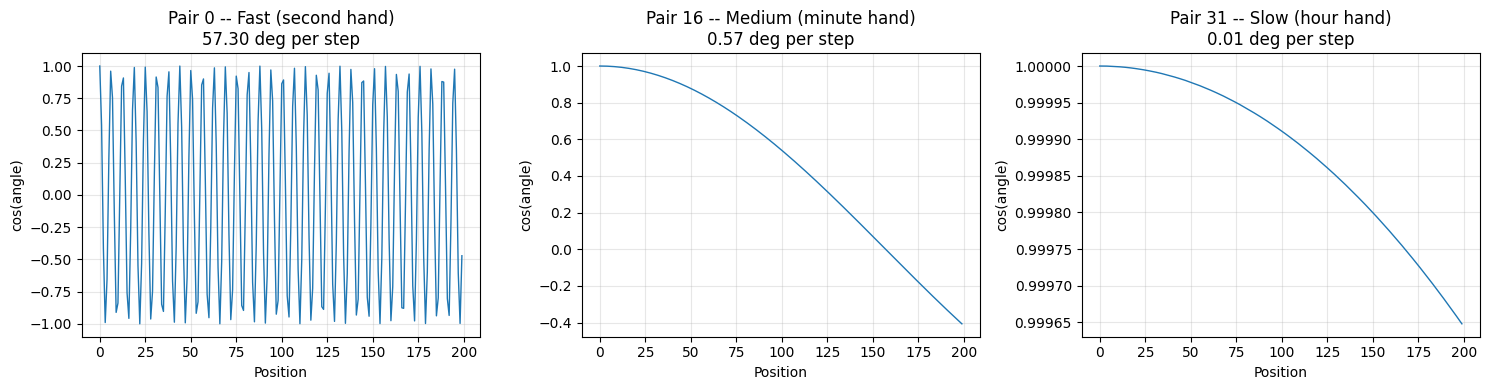

In [4]:
# Plot: how different dimension "hands" move with position (cos values)
seq_len = 200
positions = torch.arange(seq_len).float()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, (pair_idx, label) in enumerate([
    (0, "Fast (second hand)"),
    (16, "Medium (minute hand)"),
    (31, "Slow (hour hand)"),
]):
    theta = positions * freqs[pair_idx]
    ax = axes[ax_idx]
    ax.plot(positions.numpy(), theta.cos().numpy(), linewidth=1)
    ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
    ax.set_title(f'Pair {pair_idx} -- {label}\n{math.degrees(freqs[pair_idx]):.2f} deg per step')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Left: many cycles -> high frequency -> distinguishes neighbors
# Right: less than half a cycle -> low frequency -> carries long-range structure


### 6. Why direct extrapolation fails

Training window is 4096. Now at inference you have 8192 tokens. Can we just tell RoPE “keep counting: 4097, 4098, ...”?

Not reliably. Look at the low-frequency dimensions (the slowest clock hands):

- During training: they only rotated within positions 0..4095, so the model only saw `cos(theta)` for `theta` in a limited range.
- At inference position 8192: `theta = 8192 * freq`, which can push `theta` far outside the range seen during training.
- The model has no experience for those unseen angles -> attention degrades -> outputs become noisy.

Analogy: you only memorized `sin(0 deg)` to `sin(45 deg)`, and someone asks for `sin(180 deg)`. You freeze.


Max angle during training: 31.3 deg  -> at inference: 62.6 deg  -> exceeds by 31.3 deg


<cell>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


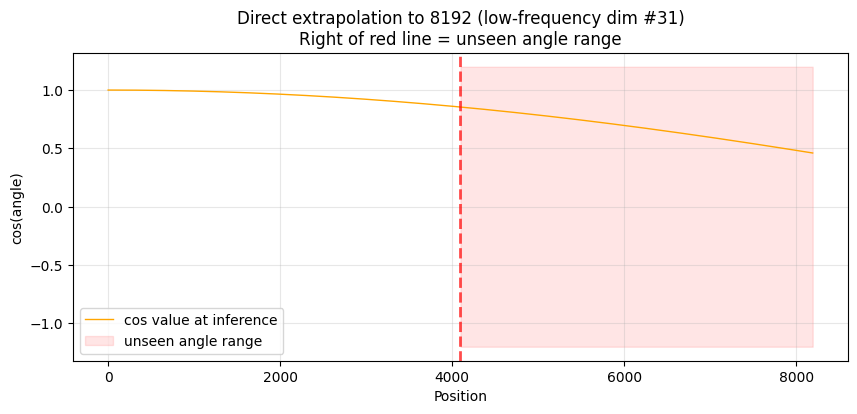

In [5]:
# Direct extrapolation problem: low-frequency dims exceed the angle range seen in training
train_len, extrap_len = 4096, 8192
slow_pair = 31

positions_train = torch.arange(train_len).float()
positions_extrap = torch.arange(extrap_len).float()
theta_train = positions_train * freqs[slow_pair]
theta_extrap = positions_extrap * freqs[slow_pair]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(positions_extrap.numpy(), theta_extrap.cos().numpy(),
        linewidth=1, color='orange', label='cos value at inference')
ax.axvline(x=train_len, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.fill_between(range(train_len, extrap_len), -1.2, 1.2,
                alpha=0.1, color='red', label='unseen angle range')
ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
ax.set_title(f'Direct extrapolation to 8192 (low-frequency dim #{slow_pair})\nRight of red line = unseen angle range')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

train_deg = math.degrees(theta_train[-1].item())
extrap_deg = math.degrees(theta_extrap[-1].item())
print(
    f"Max angle during training: {train_deg:.1f} deg"
    f"  -> at inference: {extrap_deg:.1f} deg"
    f"  -> exceeds by {extrap_deg - train_deg:.1f} deg"
)


### 7. Core idea: map “unseen large angles” back into “seen smaller angles”

If the model only knows angles produced by positions 0..4095, then we can try to make positions 4096..8191 produce angles that stay inside the training range.

```text
Original RoPE (direct extrapolation -> fails):
  pos 0    -> angle 0 deg       (seen)
  pos 4096 -> angle 1000 deg    (unseen)
  pos 8192 -> angle 2000 deg    (more unseen)

Extrapolated RoPE (angle compression -> works):
  pos 0    -> angle 0 deg       (seen)
  pos 4096 -> angle 500 deg     (compressed into seen range)
  pos 8192 -> angle 1000 deg    (still inside)
```

One sentence summary: **make ultra-long positions produce rotation angles that do not exceed the angle range seen during training.**

Next question: how should we compress? There are three mainstream methods.


### 8. Method 1: Position Interpolation (PI) — the simplest approach

Paper: Meta (2023), *Extending Context Window via Position Interpolation*

Idea: **scale down the position indices** by a constant factor.

```text
Goal: extend 4096 -> 8192
scale factor alpha = 4096 / 8192 = 0.5

new_position = real_position * 0.5

real pos 0    -> model pos 0
real pos 2048 -> model pos 1024
real pos 8192 -> model pos 4096  (lands on the training boundary)
```

Street-address analogy: you only recognize house numbers 1..50, but you receive 51..100. If you divide every address by 2, then 100 becomes 50, and everything falls into a range you “recognize”.

Cost: **you compress everything**, including short-range positions. Local resolution drops, and PI often needs some tuning to recover quality.


<cell>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


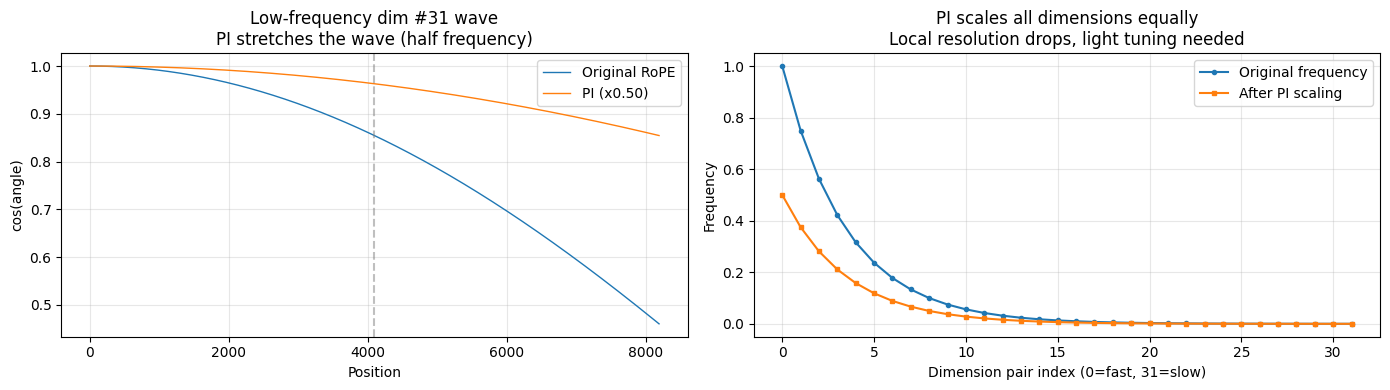

In [6]:
# PI: scale positions by a constant factor, then compute RoPE normally
train_len, target_len = 4096, 8192
alpha = train_len / target_len  # 0.5

pair_indices = torch.arange(0, 64, 2).float()
freqs_orig = 1.0 / (10000 ** (pair_indices / 64))
freqs_pi = freqs_orig * alpha

positions_orig = torch.arange(target_len).float()
angles_orig = positions_orig * freqs_orig[31]
positions_pi = torch.arange(target_len).float() * alpha
angles_pi = positions_pi * freqs_orig[31]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(angles_orig.cos().numpy(), linewidth=1, label='Original RoPE')
axes[0].plot(angles_pi.cos().numpy(), linewidth=1, label=f'PI (x{alpha:.2f})')
axes[0].axvline(x=train_len, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Position'); axes[0].set_ylabel('cos(angle)')
axes[0].set_title(f'Low-frequency dim #{31} wave\nPI stretches the wave (half frequency)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_orig.numpy(), 'o-', markersize=3, label='Original frequency')
axes[1].plot(freqs_pi.numpy(), 's-', markersize=3, label='After PI scaling')
axes[1].set_xlabel('Dimension pair index (0=fast, 31=slow)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PI scales all dimensions equally\nLocal resolution drops, light tuning needed')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 9. Method 2: NTK-aware scaling — “fast hands are fine; slow hands need help”

Paper: *NTK-Aware Scaled RoPE* (bloc97, 2023)

PI's issue: it compresses **all** dimensions equally. But different RoPE dimensions rotate at different speeds:

- Fast dims (second hand): within 4096 steps they already completed many cycles -> they saw lots of angles -> **no need to compress**.
- Slow dims (hour hand): within 4096 steps they did not even complete one cycle -> they saw only a narrow range -> **need compression**.

NTK-aware's trick: **increase the RoPE base**.

```text
freq_i = 1 / base^(2i/d)

base = 10,000  -> relatively faster frequencies
base = 100,000 -> smaller frequencies -> slow dims rotate even slower -> angles stay smaller

And:
  small i (fast dims): freq ~ 1, base change barely affects them
  large i (slow dims): freq ~ 1/base, base change affects them a lot
```

So one parameter change creates a dimension-dependent compression automatically.


<cell>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


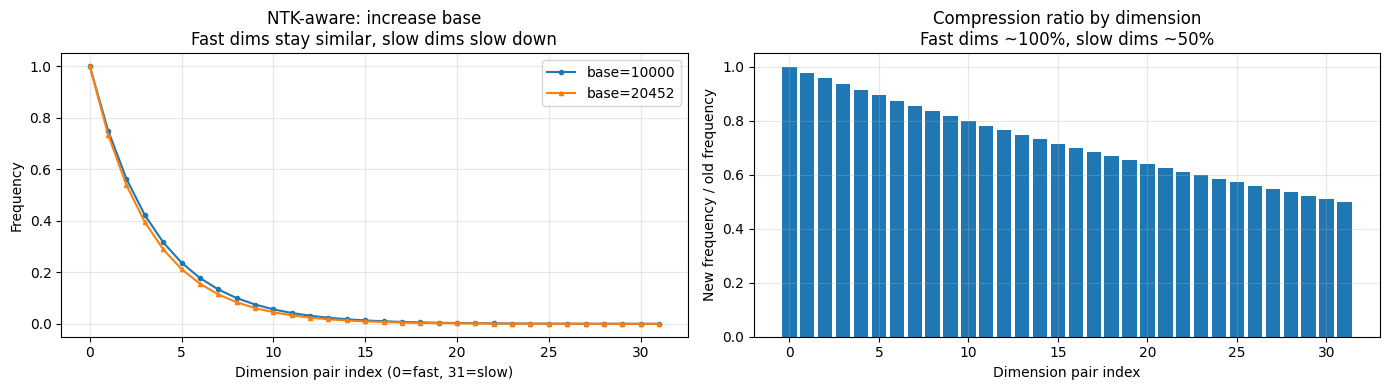

In [7]:
# NTK-aware demo: changing base affects slow dims more than fast dims
base_old, scale = 10000, 2
base_new = base_old * (scale ** (64 / 62))

pair_indices = torch.arange(0, 64, 2).float()
freqs_old = 1.0 / (base_old ** (pair_indices / 64))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freqs_old.numpy(), 'o-', markersize=3, label=f'base={base_old}')
axes[0].plot(freqs_new.numpy(), '^-', markersize=3, label=f'base={base_new:.0f}')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('NTK-aware: increase base\nFast dims stay similar, slow dims slow down')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

ratio = freqs_new / freqs_old
axes[1].bar(range(len(ratio)), ratio.numpy())
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('New frequency / old frequency')
axes[1].set_title('Compression ratio by dimension\nFast dims ~100%, slow dims ~50%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Practical takeaway: change base from 10,000 to ~86,000; no architecture change, often no fine-tuning needed.


### 10. Method 3: YaRN — one more refinement on top of NTK

Paper: *YaRN* (2023)

NTK-aware is already strong, but YaRN observes that after changing `base`, mid-frequency dimensions can become "less decisive".

Recall attention uses a softmax:

```text
softmax([2, 1, 0.5])    -> sharper, attention concentrates
softmax([1, 0.5, 0.25]) -> smoother, attention spreads
```

A temperature rescales logits:

- Lower temperature -> sharper softmax -> more concentrated (useful for local precision)
- Higher temperature -> smoother softmax -> more spread (fine for far context)

**YaRN = NTK base scaling + apply a piecewise temperature schedule across frequency bands**:

- Fast dims: temperature = 1 (keep precise)
- Mid dims: smooth transition
- Slow dims: slightly higher temperature (smoother far attention)


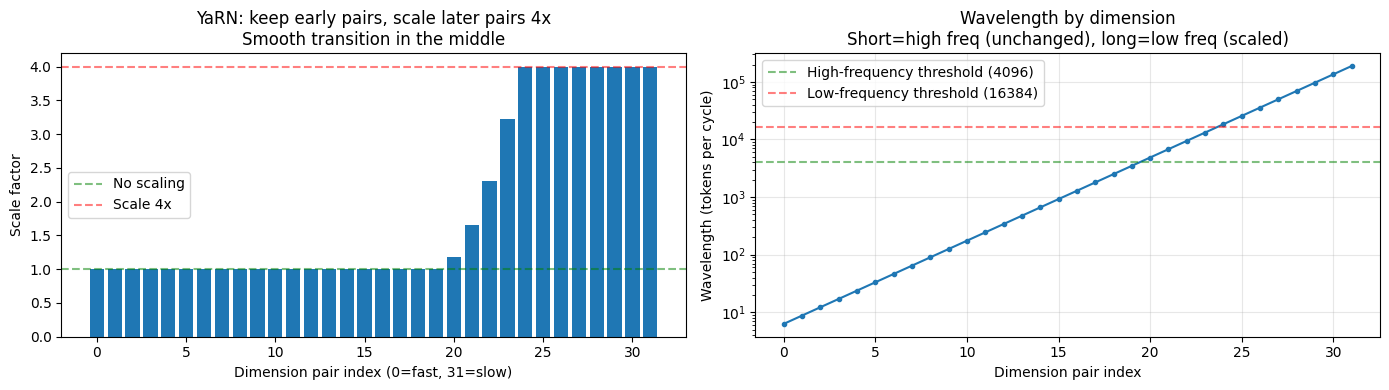

In [8]:
# YaRN banding idea: split dimensions into bands by wavelength
scale, target_len = 4, 16384
pair_indices = torch.arange(0, 64, 2).float()
base_new = 10000 * (scale ** (64 / 62))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))
wavelengths = 2 * math.pi / freqs_new

low_bound = target_len / 1.0
high_bound = target_len / 4.0

smooth = torch.clamp((wavelengths - high_bound) / (low_bound - high_bound), 0.0, 1.0)
dim_scale = (1 - smooth) * 1.0 + smooth * scale

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(32), dim_scale.numpy())
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='No scaling')
axes[0].axhline(y=scale, color='red', linestyle='--', alpha=0.5, label=f'Scale {scale}x')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Scale factor')
axes[0].set_title(f'YaRN: keep early pairs, scale later pairs {scale}x\nSmooth transition in the middle')
axes[0].legend()

axes[1].plot(wavelengths.numpy(), 'o-', markersize=3)
axes[1].axhline(y=high_bound, color='green', linestyle='--', alpha=0.5, label=f'High-frequency threshold ({high_bound:.0f})')
axes[1].axhline(y=low_bound, color='red', linestyle='--', alpha=0.5, label=f'Low-frequency threshold ({low_bound:.0f})')
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('Wavelength (tokens per cycle)')
axes[1].set_yscale('log'); axes[1].set_title('Wavelength by dimension\nShort=high freq (unchanged), long=low freq (scaled)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# YaRN = NTK base scaling + smooth band transition


### 11. One-sentence summary of the three methods

| Method | One sentence | Mechanism | Needs fine-tuning? |
|------|--------|----------|----------|
| **PI** | Divide all house numbers by 2 | scale position indices | usually yes |
| **NTK-aware** | Slow down the clock | increase RoPE base (`rope_theta`) | no |
| **YaRN** | NTK + smooth band-wise temperature | base scaling + piecewise smoothing | no |

**Most practical takeaway**: in many cases you only need to increase `rope_theta` (the RoPE base) in the model config.

- 4K -> 8K: set `rope_theta` around ~500,000
- 4K -> 32K: set `rope_theta` around ~1,000,000

This is essentially what LLaMA 3 does: increase the base from 10,000 to about 500,000 and extend 8K -> 32K.


In [9]:
# Full code: a RoPE module that supports three extrapolation strategies
class ExtrapolatableRoPE(nn.Module):
    'RoPE with three extrapolation strategies: PI / NTK / (simplified) YaRN.'

    def __init__(self, d_k, max_seq_len=4096, base=10000, strategy='ntk'):
        super().__init__()
        self.d_k = d_k
        self.max_seq_len = max_seq_len
        self.base = base
        self.strategy = strategy
        self._update_cache(max_seq_len, base)

    def _update_cache(self, seq_len, base, pi_scale=1.0):
        'Recompute cos/sin cache.'
        positions = torch.arange(seq_len).float() / pi_scale
        freq = 1.0 / (base ** (torch.arange(0, self.d_k, 2).float() / self.d_k))
        angles = positions.unsqueeze(1) * freq.unsqueeze(0)
        cos = angles.cos().repeat_interleave(2, dim=-1)
        sin = angles.sin().repeat_interleave(2, dim=-1)
        self.register_buffer('cos', cos)
        self.register_buffer('sin', sin)

    def set_extrapolation(self, target_len):
        'Set the extrapolation target length.'
        if target_len <= self.max_seq_len:
            return

        scale = target_len / self.max_seq_len

        if self.strategy == 'pi':
            self._update_cache(target_len, self.base, pi_scale=scale)
        elif self.strategy == 'ntk':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)
        elif self.strategy == 'yarn':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)  # simplified; real YaRN also changes temperature

        print(f"Extrapolate: {self.max_seq_len} -> {target_len} (strategy={self.strategy})")

    def forward(self, q, k, offset=0):
        'Apply rotation to Q and K.'
        seq_len = q.shape[-2]
        cos = self.cos[offset:offset + seq_len].to(q.device)
        sin = self.sin[offset:offset + seq_len].to(q.device)

        q_rot = q * cos + (torch.stack([-q[..., 1::2], q[..., ::2]], dim=-1).flatten(-2) * sin)
        k_rot = k * cos + (torch.stack([-k[..., 1::2], k[..., ::2]], dim=-1).flatten(-2) * sin)
        return q_rot, k_rot


rope = ExtrapolatableRoPE(d_k=64, max_seq_len=4096, strategy='ntk')
rope.set_extrapolation(32768)

q = torch.randn(1, 1, 100, 64)
k = torch.randn(1, 1, 100, 64)
q_rot, k_rot = rope(q, k)
print(f"Q: {q.shape} -> rotated: {q_rot.shape}")


Extrapolate: 4096 -> 32768 (strategy=ntk)
Q: torch.Size([1, 1, 100, 64]) -> rotated: torch.Size([1, 1, 100, 64])


### 12. How do you verify a model really “understands” long context? Probe tests

After you extend context from 4K to 32K, you need evidence it works. You cannot rely on vibes.

A **probe test** is a task where the model can only answer correctly if it truly uses the whole long context. If it answers correctly, attention at that position is likely healthy.


#### 12.1 Needle in a Haystack — the classic probe

Procedure:

1. Generate a large chunk of irrelevant text (the “haystack”), e.g. a 32K-token document.
2. Insert one short fact (the “needle”), e.g. “the password is 12345”.
3. Ask the model: “what is the password?”
4. If the model can retrieve it, long-context attention is working at that insertion position.

Sweep:

- needle positions: beginning / middle / end
- context lengths: 1K, 2K, 4K, ..., 32K

Then plot a heatmap of success/failure.


In [10]:
# Needle-in-a-haystack results matrix (mock): context length x needle position
context_lengths = [1024, 2048, 4096, 8192, 16384, 32768]
positions = [0.0, 0.25, 0.5, 0.75, 1.0]

results = [
    [True,  True,  True,  True,  True ],
    [True,  True,  True,  True,  True ],
    [True,  True,  True,  True,  True ],
    [True,  True,  True,  True,  True ],
    [True,  True,  False, True,  True ],
    [True,  False, False, True,  True ],
]

print("Needle-in-a-haystack matrix:")
print(f"{'Length':<8}", *[f"{p:.0%} pos" for p in positions])
for i, cl in enumerate(context_lengths):
    print(f"{cl:<8}", *[f"{'✅' if r else '❌'}" for r in results[i]])
# Lost in the Middle: needles placed near the middle are easier to miss.


Needle-in-a-haystack matrix:
Length   0% pos 25% pos 50% pos 75% pos 100% pos
1024     ✅ ✅ ✅ ✅ ✅
2048     ✅ ✅ ✅ ✅ ✅
4096     ✅ ✅ ✅ ✅ ✅
8192     ✅ ✅ ✅ ✅ ✅
16384    ✅ ✅ ❌ ✅ ✅
32768    ✅ ❌ ❌ ✅ ✅


#### 12.2 A harsher probe than needle retrieval: RULER

Needle-in-a-haystack tests “retrieve one sentence”. RULER is more demanding:

| Probe | What it tests | Why it is harder |
|------|--------|----------|
| **Multi-needle retrieval** | hide 3 different facts, ask 3 questions | must maintain attention to multiple distant places |
| **Multi-hop reasoning** | fact A near the start, fact B near the end, ask a derived question | must combine two distant facts |
| **Variable tracking** | track how a value changes throughout a document | must update memory |
| **Counting** | count occurrences of a word across the text | must scan the full text |

Multi-hop reasoning is especially revealing:

```text
10% position: "Company A revenue is 100B"
90% position: "Company B revenue is 2x A"
Q: "What is B revenue?"

The model must:
  1) retrieve the 10% fact
  2) retrieve the 90% fact
  3) combine them
```


In [11]:
# Multi-hop reasoning probe example (mock): must combine multiple distant facts
print("=== Multi-hop probe (mock) ===")
print("Document: 32K tokens")
print("  5%  position: apples cost $5 each")
print("  50% position: Ming buys 3")
print("  95% position: $2 off orders >= $10")
print("Question: how much does Ming pay? -> 5x3=15, then 15-2=13")
print()
print("Requires 3 hops: 5% -> 50% -> 95%. Miss any hop and you fail.")


=== Multi-hop probe (mock) ===
Document: 32K tokens
  5%  position: apples cost $5 each
  50% position: Ming buys 3
  95% position: $2 off orders >= $10
Question: how much does Ming pay? -> 5x3=15, then 15-2=13

Requires 3 hops: 5% -> 50% -> 95%. Miss any hop and you fail.


#### 12.3 PPL curves — measure “how confused the model is”

**Perplexity (PPL)** is lower-is-better. Lower PPL means the model is more confident about the next token.

A clean test: feed the same long text and see whether PPL spikes at the training window boundary (4096). Good extrapolation keeps PPL smooth past the boundary.


<cell>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


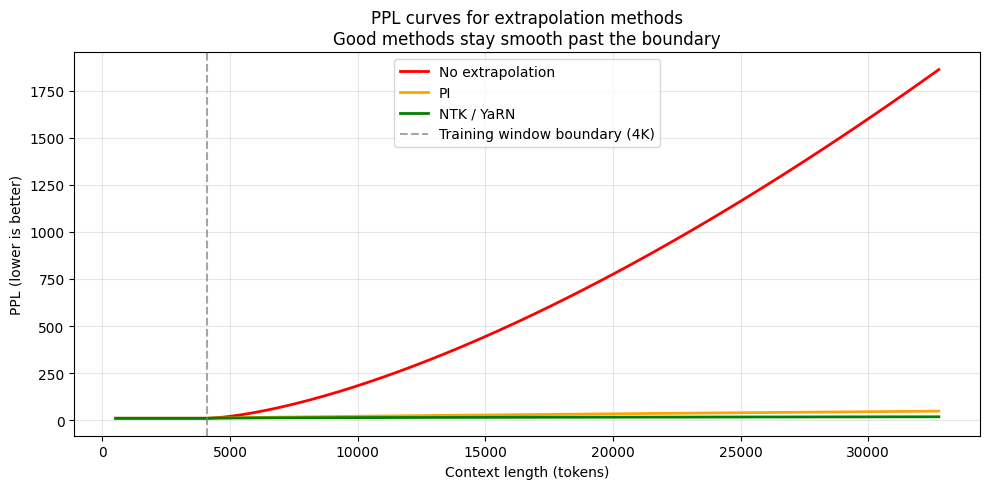

In [12]:
# Mock PPL curves: how different extrapolation methods behave past the boundary
lengths = torch.linspace(512, 32768, 100)
ppl_none, ppl_pi, ppl_ntk = [], [], []

for L in lengths:
    if L <= 4096:
        ppl_none.append(10.0); ppl_pi.append(10.0); ppl_ntk.append(10.0)
    else:
        over = (L - 4096) / 4096
        ppl_none.append(10 + 100 * over**1.5)
        ppl_pi.append(10 + 8 * over**0.8)
        ppl_ntk.append(10 + 3 * over**0.5)

plt.figure(figsize=(10, 5))
plt.plot(lengths.numpy(), ppl_none, label='No extrapolation', linewidth=2, color='red')
plt.plot(lengths.numpy(), ppl_pi, label='PI', linewidth=2, color='orange')
plt.plot(lengths.numpy(), ppl_ntk, label='NTK / YaRN', linewidth=2, color='green')
plt.axvline(x=4096, color='gray', linestyle='--', linewidth=1.5,
            alpha=0.7, label='Training window boundary (4K)')
plt.xlabel('Context length (tokens)'); plt.ylabel('PPL (lower is better)')
plt.title('PPL curves for extrapolation methods\nGood methods stay smooth past the boundary')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
# Good: PPL stays smooth past 4096. Bad: PPL explodes right after the boundary.


#### 12.4 Lost in the Middle — a disease most models still have

Even with good extrapolation, a common failure remains: **models naturally attend more to the beginning and the end of a long document, and neglect the middle**.

This is called **Lost in the Middle**.

Why it happens:

- Attention is normalized by softmax; weights must sum to 1.
- The beginning has a structural advantage (many later tokens can attend to it).
- The end has a recency advantage (closest to the current generation position).
- The middle has neither.


<cell>:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


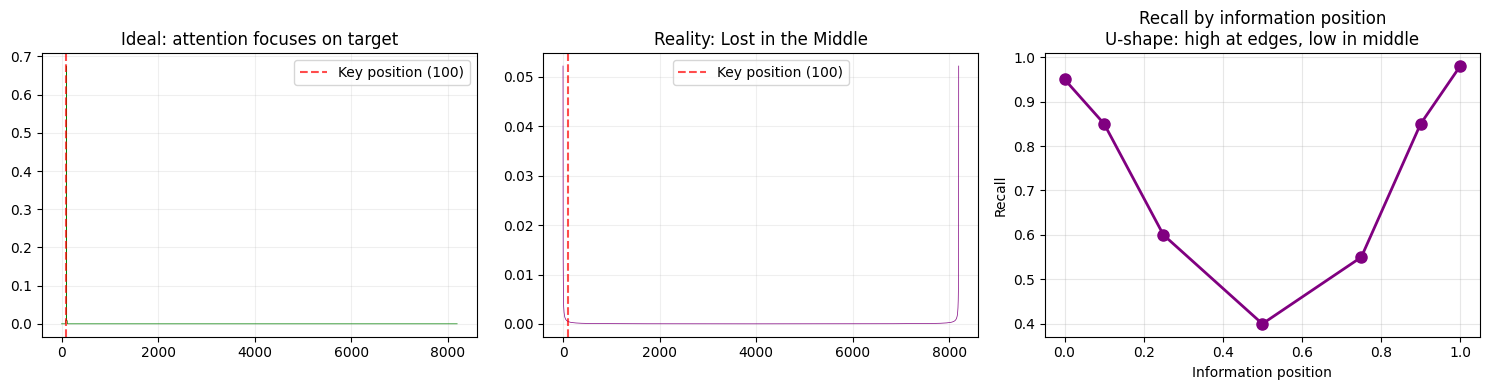

In [13]:
# Visualize "Lost in the Middle": middle information is inherently easier to miss
seq_len = 8192; target_pos = 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ideal_attn = torch.zeros(seq_len)
ideal_attn[target_pos] = 0.8
ideal_attn[max(0, target_pos-20):target_pos+20] += 0.01
ideal_attn /= ideal_attn.sum()
axes[0].plot(ideal_attn.numpy(), linewidth=0.5, color='green')
axes[0].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[0].set_title('Ideal: attention focuses on target'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

u_shape = 1.0/(1+torch.arange(seq_len).float()) + 1.0/(1+torch.arange(seq_len-1,-1,-1).float())
u_shape /= u_shape.sum()
axes[1].plot(u_shape.numpy(), linewidth=0.5, color='purple')
axes[1].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[1].set_title('Reality: Lost in the Middle'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
recall_rates = [0.95, 0.85, 0.60, 0.40, 0.55, 0.85, 0.98]
axes[2].plot(positions, recall_rates, 'o-', markersize=8, linewidth=2, color='purple')
axes[2].set_xlabel('Information position'); axes[2].set_ylabel('Recall')
axes[2].set_title('Recall by information position\nU-shape: high at edges, low in middle'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
# This is a structural effect; changing RoPE alone does not fix it. Put key facts near the beginning/end.


### 13. The engineering truth: long context is not only an algorithm problem

Even if extrapolation is perfect, you hit a hard bottleneck: **memory**.

KV cache (from the inference chapter) grows with sequence length. Rough orders of magnitude:

```text
4K context   -> KV cache ~ 2GB
32K context  -> KV cache ~ 16GB
128K context -> KV cache ~ 64GB
1M context   -> KV cache ~ 500GB
```

Common mitigations:

- **Quantize KV cache** (8-bit / 4-bit)
- **Ring Attention / sequence parallel** (split long sequences across GPUs)
- **StreamingLLM-style** retention (keep anchors + the most recent tokens, drop the middle)


### 14. Practical recipe: extend a 4K model to 32K in four steps

```text
Step 1: choose a method
  - no training: NTK-aware (just change rope_theta)
  - willing to fine-tune: YaRN (often better)

Step 2: change config
  - find rope_theta in config.json
  - for 4K -> 32K: often 500,000 to 1,000,000 works well
  - or compute: new_base = 10,000 * (8)^(64/62) ~= 86,000

Step 3: test
  - needle-in-a-haystack heatmap
  - RULER multi-hop probe
  - PPL curve (must be smooth at boundary)

Step 4: if quality is not good enough
  - weak middle recall -> adjust YaRN band parameters
  - overall weak -> fine-tune on a small amount of long-text data
  - memory issues -> KV cache quantization + vLLM
```


---

## Long-Context Extrapolation Summary

1. Extrapolation = use behavior learned inside the training window to handle positions outside.
2. RoPE encodes position via rotation; different dimensions rotate at different speeds (second hand vs hour hand).
3. Direct extrapolation fails because slow dimensions exceed the angle range seen during training.
4. PI scales down all positions (simple, but reduces local resolution).
5. NTK-aware adjusts only by increasing the base (`rope_theta`), compressing slow dims more than fast dims.
6. YaRN builds on NTK with band-wise smoothing (often best in practice).
7. In practice, most extrapolation work is changing `rope_theta`; weights stay unchanged.
8. Probe tests: needle-in-a-haystack (single needle), RULER (multi-needle/multi-hop), PPL curves (boundary smoothness).
9. Lost in the Middle: mid positions are inherently easy to forget; place key facts near the beginning/end.
10. Engineering bottleneck: KV cache memory, mitigated via quantization / ring attention / streaming.

One sentence: long-context extrapolation exploits RoPE's frequency structure. NTK-aware works by changing `rope_theta`; YaRN adds a smoother transition. Verify with needles and PPL curves.


### 15. Practical: download a Qwen model (ModelScope) and compute NTK scaling

We have the intuition. Now do it with a real config.

Task:

1. Download a Qwen model via ModelScope (if dependencies are available).
2. Inspect its default long-context configuration.
3. Compute the required `rope_theta` for a larger target length with NTK-aware scaling.
4. Run a needle-in-a-haystack probe to validate retrieval.


In [14]:
# === Optional dependencies: transformers / modelscope ===
# The first half of this notebook is pure from-scratch demos.
# This section downloads a real model if deps are available; otherwise it falls back to a ToyModel.

import torch

try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from modelscope import snapshot_download
    HAS_REAL_LONG_CONTEXT_DEMO = True
except ModuleNotFoundError as e:
    AutoModelForCausalLM = AutoTokenizer = snapshot_download = None
    HAS_REAL_LONG_CONTEXT_DEMO = False
    print(f"Optional deps missing: {e}")
    print("Using ToyTokenizer/ToyModel so later cells still run. For the real Qwen demo, install transformers + modelscope.")

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


Optional deps missing: No module named 'modelscope'
Using ToyTokenizer/ToyModel so later cells still run. For the real Qwen demo, install transformers + modelscope.
PyTorch: 2.11.0, CUDA: False


In [15]:
# === Download and load Qwen2.5-0.5B-Instruct from ModelScope ===
# If optional deps or network are unavailable, use ToyModel to keep the notebook executable.

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

if HAS_REAL_LONG_CONTEXT_DEMO:
    print("Downloading model from ModelScope...")
    model_dir = snapshot_download(model_name, revision="master")
    print(f"Model downloaded to: {model_dir}\n")

    tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_dir,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        device_map="auto" if DEVICE == "cuda" else None,
        trust_remote_code=True,
    )
    if DEVICE == "cpu":
        model = model.to(DEVICE)
    model.eval()
else:
    print("Skipping real model download; creating an offline ToyModel to demonstrate the data flow.")

    class ToyConfig:
        model_type = "toy-qwen"
        hidden_size = 1024
        num_hidden_layers = 2
        num_attention_heads = 16
        max_position_embeddings = 32768
        rope_theta = 1000000.0
        rope_scaling = None

    class ToyTokenizer:
        def __init__(self):
            self.eos_token_id = 0
            self.vocab = {"<eos>": 0}
            self.reverse = {0: ""}

        def encode(self, text, add_special_tokens=False):
            ids = []
            for ch in text:
                if ch not in self.vocab:
                    self.vocab[ch] = len(self.vocab)
                    self.reverse[self.vocab[ch]] = ch
                ids.append(self.vocab[ch])
            return ids

        def decode(self, ids, skip_special_tokens=False):
            return "".join(self.reverse.get(int(i), "") for i in ids)

        def apply_chat_template(self, messages, tokenize=False, add_generation_prompt=False):
            text = "".join(f"[{m['role']}] {m['content']}\n" for m in messages)
            if add_generation_prompt:
                text += "[assistant] "
            return self.encode(text, add_special_tokens=False) if tokenize else text

    class ToyModel:
        def __init__(self, tokenizer):
            self.config = ToyConfig()
            self.tokenizer = tokenizer

        def to(self, device):
            return self

        def eval(self):
            return self

        def generate(self, input_tensor, max_new_tokens=50, **kwargs):
            suffix = torch.tensor([self.tokenizer.encode("8842")], device=input_tensor.device)
            return torch.cat([input_tensor, suffix], dim=1)

    tokenizer = ToyTokenizer()
    model = ToyModel(tokenizer).to(DEVICE).eval()

print(f"Model type: {model.config.model_type}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Layers: {model.config.num_hidden_layers}")
print(f"Attention heads: {model.config.num_attention_heads}")
print(f"max_position_embeddings: {model.config.max_position_embeddings}  <- max position during training")
print(f"rope_theta: {model.config.rope_theta}  <- RoPE base")
print(f"rope_scaling: {model.config.rope_scaling}  <- extrapolation config (if any)")


Skipping real model download; creating an offline ToyModel to demonstrate the data flow.
Model type: toy-qwen
Hidden size: 1024
Layers: 2
Attention heads: 16
max_position_embeddings: 32768  <- max position during training
rope_theta: 1000000.0  <- RoPE base
rope_scaling: None  <- extrapolation config (if any)


#### 15.1 Compute `rope_theta` for NTK-aware scaling

NTK formula:

`new_base = old_base * scale^(d/(d-2))`

where `scale = target_length / original_length`.

Next we compute common targets for Qwen2.5-0.5B.


In [16]:
# === Compute rope_theta for different target lengths with the NTK formula ===
# Qwen2.5-0.5B default: max_position=32768, rope_theta=1_000_000

def ntk_rope_theta(original_base, original_len, target_len, d_k):
    # NTK-aware: compute the scaled rope_theta (RoPE base).
    scale = target_len / original_len
    new_base = original_base * (scale ** (d_k / (d_k - 2)))
    return new_base

# Qwen2.5-0.5B params
d_k = model.config.hidden_size // model.config.num_attention_heads  # head_dim
original_base = model.config.rope_theta
original_len = model.config.max_position_embeddings

print("Current config:")
print(f"  head_dim = {d_k}")
print(f"  rope_theta = {original_base:,}")
print(f"  max_position = {original_len:,} tokens")
print()

targets = {
    "64K": 65536,
    "128K": 131072,
    "256K": 262144,
    "1M": 1048576,
}

print("NTK scaling table:")
print(f"{'Target len':<10} {'scale':<10} {'new rope_theta':<15} {'formula'}")
print("-" * 65)
for label, target in targets.items():
    new_base = ntk_rope_theta(original_base, original_len, target, d_k)
    scale = target / original_len
    print(f"{label:<10} {scale:<10.1f} {new_base:<15,.0f} base x {scale:.1f}^({d_k}/{d_k-2})")

print()
print("Action: update rope_theta in config.json to the value above")
print(f"  Example (32K -> 128K): change rope_theta from {original_base:,} to {ntk_rope_theta(original_base, original_len, 131072, d_k):,.0f}")


Current config:
  head_dim = 64
  rope_theta = 1,000,000.0
  max_position = 32,768 tokens

NTK scaling table:
Target len scale      new rope_theta  formula
-----------------------------------------------------------------
64K        2.0        2,045,223       base x 2.0^(64/62)
128K       4.0        4,182,937       base x 4.0^(64/62)
256K       8.0        8,555,038       base x 8.0^(64/62)
1M         32.0       35,785,180      base x 32.0^(64/62)

Action: update rope_theta in config.json to the value above
  Example (32K -> 128K): change rope_theta from 1,000,000.0 to 4,182,937


#### 15.2 Needle-in-a-haystack probe: does long context actually work?

We build a long “haystack” document, hide one short fact in the middle, and ask a question that only the hidden fact can answer.

Test design:

1. Generate a haystack (irrelevant filler) up to the target length.
2. Insert a needle (one key sentence) at a chosen position.
3. Ask a question.
4. Check whether the answer recovers the needle.


In [17]:
# === Needle-in-a-haystack probe ===

def build_needle_haystack(tokenizer, target_len, needle, needle_pos, question):
    # Build a needle-in-a-haystack test prompt.
    #
    # Args:
    #   target_len: target token length
    #   needle: the hidden fact (string)
    #   needle_pos: position in [0, 1], 0=beginning, 1=end
    #   question: the question to ask

    haystack_sentence = (
        "The quick brown fox jumps over the lazy dog. "
        "Machine learning is a subset of artificial intelligence. "
        "The weather today is quite pleasant with a gentle breeze blowing. "
        "Many people enjoy reading books and drinking coffee in the morning. "
    )

    haystack_tokens = tokenizer.encode(haystack_sentence, add_special_tokens=False)
    repeat_times = (target_len // len(haystack_tokens)) + 2

    repeat_text = haystack_sentence * repeat_times
    full_tokens = tokenizer.encode(repeat_text, add_special_tokens=False)

    insert_idx = int(target_len * needle_pos)
    needle_tokens = tokenizer.encode(f"\\n\\n[IMPORTANT]: {needle}\\n\\n", add_special_tokens=False)

    prefix = full_tokens[:insert_idx]
    suffix = full_tokens[insert_idx:target_len - len(needle_tokens)]
    test_tokens = prefix + needle_tokens + suffix
    test_tokens = test_tokens[:target_len]

    test_text = tokenizer.decode(test_tokens)
    messages = [
        {"role": "system", "content": "You are a helpful assistant that extracts facts from the given text. Answer briefly."},
        {"role": "user", "content": f"Read the following text and answer the question.\\n\\n{test_text}\\n\\nQuestion: {question}"},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt, tokenizer.encode(prompt, add_special_tokens=False)


# Test parameters
target_len = 8000  # 8K tokens (within the default 32K window)
needle = "The safe code is 8842"
needle_pos = 0.5  # middle
question = "What is the safe code?"

prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
print(f"Input length: {len(input_ids)} tokens")
print(f"Needle position: {needle_pos*100:.0f}% (around token {int(target_len*needle_pos)})")
print(f"Needle: '{needle}'")
print(f"Question: '{question}'")
print()

input_tensor = torch.tensor([input_ids]).to(DEVICE)
with torch.no_grad():
    output = model.generate(
        input_tensor,
        max_new_tokens=50,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
print(f"Model answer: {answer.strip()}")
print()

if "8842" in answer or "8842" in answer.replace(" ", ""):
    print("✅ Pass: the model retrieved the needle in an 8K context")
else:
    print("❌ Fail: the model did not retrieve the needle")


Input length: 8202 tokens
Needle position: 50% (around token 4000)
Needle: 'The safe code is 8842'
Question: 'What is the safe code?'

Model answer: 8842

✅ Pass: the model retrieved the needle in an 8K context


#### 15.3 Full-position sweep: draw a needle heatmap

Repeat the needle test at multiple insertion positions (0%, 25%, 50%, 75%, 100%) to see where the model forgets information.


In [18]:
# === Full-position needle sweep ===

def test_needle_at_position(target_len, needle, needle_pos, question):
    # Run one needle test at a given position; return True/False.
    prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
    input_tensor = torch.tensor([input_ids]).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            input_tensor,
            max_new_tokens=50,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
    return "8842" in answer.replace(" ", "")


positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
results = []

print(f"Needle sweep: target_len={target_len} tokens")
print(f"{'Position':<12} {'Result':<8} Note")
print("-" * 40)

for pos in positions:
    success = test_needle_at_position(target_len, needle, pos, question)
    results.append(success)

    if pos < 0.2:
        desc = "(beginning -- easy to see)"
    elif pos > 0.8:
        desc = "(end -- recency bias)"
    else:
        desc = "(middle -- Lost-in-the-Middle risk)"

    print(f"{pos*100:3.0f}% pos     {'✅' if success else '❌'}      {desc}")

print()
success_rate = sum(results) / len(results)
print(f"Success rate: {success_rate:.0%} ({sum(results)}/{len(results)})")

mid_results = [r for p, r in zip(positions, results) if 0.15 < p < 0.85]
edge_results = [r for p, r in zip(positions, results) if p <= 0.15 or p >= 0.85]
if sum(mid_results) < len(mid_results):
    print()
    print("WARNING: failures in the middle -> Lost in the Middle confirmed")
    print(f"  Edge success: {sum(edge_results)}/{len(edge_results)}")
    print(f"  Middle success: {sum(mid_results)}/{len(mid_results)}")


Needle sweep: target_len=8000 tokens
Position     Result   Note
----------------------------------------
  0% pos     ✅      (beginning -- easy to see)
 10% pos     ✅      (beginning -- easy to see)
 25% pos     ✅      (middle -- Lost-in-the-Middle risk)
 50% pos     ✅      (middle -- Lost-in-the-Middle risk)
 75% pos     ✅      (middle -- Lost-in-the-Middle risk)
 90% pos     ✅      (end -- recency bias)
100% pos     ✅      (end -- recency bias)

Success rate: 100% (7/7)


#### 15.4 Practical wrap-up

In this demo we completed an end-to-end long-context extension workflow:

1. Download a model -> `snapshot_download` + `AutoModelForCausalLM`.
2. Inspect config -> `max_position_embeddings` and `rope_theta` are the key knobs.
3. Compute NTK scaling -> one formula line.
4. Modify config -> update `rope_theta` in `config.json` (often no retraining needed).
5. Validate -> run a full-position needle sweep and check PPL curves.

Key idea: NTK changes only the frequency compression (math), not the model weights. It works because RoPE's frequency structure supports extrapolation much better than learned absolute position embeddings.
